In [1]:
# Langkah 1: Download data dari GitHub buku
!mkdir -p datasets/lifesat
!wget -O datasets/lifesat/oecd_bli_2015.csv https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/lifesat/oecd_bli_2015.csv
!wget -O datasets/lifesat/gdp_per_capita.csv https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/lifesat/gdp_per_capita.csv

--2025-06-19 07:55:24--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/lifesat/oecd_bli_2015.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 405467 (396K) [text/plain]
Saving to: ‘datasets/lifesat/oecd_bli_2015.csv’

datasets/lifesat/oe 100%[===================>] 395.96K  --.-KB/s    in 0.007s  

2025-06-19 07:55:24 (55.8 MB/s) - ‘datasets/lifesat/oecd_bli_2015.csv’ saved [405467/405467]

--2025-06-19 07:55:25--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/lifesat/gdp_per_capita.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTT

In [2]:
# Langkah 2: Import library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
# Langkah 3: Siapkan data
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["Indicator"] == "Life satisfaction"]
    oecd_bli = oecd_bli[oecd_bli["Inequality"] == "Total"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    return full_country_stats[["GDP per capita", "Life satisfaction"]]

# Load data
oecd_bli = pd.read_csv("datasets/lifesat/oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv("datasets/lifesat/gdp_per_capita.csv", thousands=',', delimiter='\t',
                             encoding='latin1', na_values="n/a")

country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)

X = country_stats[["GDP per capita"]].values
y = country_stats["Life satisfaction"].values


Prediksi Life Satisfaction untuk Cyprus: 6.29


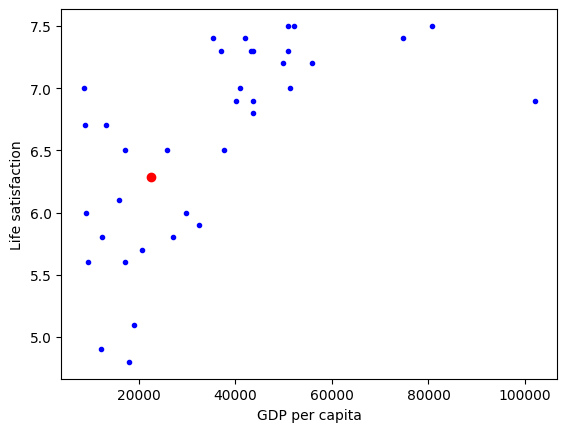

In [4]:
# Langkah 4: Latih model & prediksi
model = LinearRegression()
model.fit(X, y)

# Prediksi untuk Cyprus
X_new = [[22587]]  # GDP per capita Cyprus
y_pred = model.predict(X_new)

print(f"Prediksi Life Satisfaction untuk Cyprus: {y_pred[0]:.2f}")

# Visualisasi
plt.plot(X, y, "b.")
plt.plot(X_new, y_pred, "ro")
plt.xlabel("GDP per capita")
plt.ylabel("Life satisfaction")
plt.show()


# 📘 Bab 1: Lanskap Machine Learning

## 1. Apa Itu Machine Learning?

**Machine Learning (ML)** adalah bidang ilmu komputer yang membuat komputer mampu belajar dari data tanpa diprogram secara eksplisit.

📌 Definisi klasik:
> *Sebuah program komputer dikatakan belajar dari pengalaman E terkait tugas T dan ukuran performa P, jika performanya pada T, sebagaimana diukur oleh P, meningkat dengan pengalaman E.*  
> — *Tom Mitchell, 1997*

Contoh nyata: **filter spam** yang belajar dari email spam dan non-spam.

---

## 2. Mengapa Menggunakan Machine Learning?

ML sangat berguna ketika:
- Masalah terlalu rumit untuk diprogram secara manual.
- Data atau lingkungan terus berubah.
- Ingin menemukan pola tersembunyi dalam data besar (*data mining*).

---

## 3. Contoh Aplikasi Machine Learning

- Klasifikasi gambar (CNN)
- Deteksi tumor (semantic segmentation)
- Pengenalan suara (RNN, CNN, Transformer)
- Chatbot & asisten virtual (NLP)
- Sistem rekomendasi
- Prediksi angka (regresi)
- Deteksi penipuan (anomaly detection)
- Clustering pelanggan
- Visualisasi data berdimensi tinggi
- Agen AI dalam game (Reinforcement Learning)

---

## 4. Jenis-Jenis Machine Learning

### Berdasarkan Label:
- **Supervised Learning**: data berlabel (klasifikasi, regresi)
- **Unsupervised Learning**: data tidak berlabel (clustering, reduksi dimensi)
- **Semisupervised Learning**: kombinasi data berlabel & tidak
- **Reinforcement Learning**: belajar dari reward/punishment

### Berdasarkan Mode:
- **Batch Learning**: pelatihan dilakukan sekaligus (offline)
- **Online Learning**: pelatihan secara bertahap (real-time)

### Berdasarkan Pendekatan:
- **Instance-Based**: menyimpan dan membandingkan contoh (misal k-NN)
- **Model-Based**: membuat model matematis dari data (misal regresi linear)

---

## 5. Studi Kasus: Regresi Linear

Contoh: memprediksi tingkat kebahagiaan berdasarkan GDP per kapita.
Model:
Langkah:
- Kumpulkan data
- Pilih model (Linear Regression)
- Latih model (menentukan nilai θ)
- Gunakan model untuk prediksi (inference)

---

## 6. Tantangan dalam Machine Learning

### Masalah pada Data:
- Jumlah data pelatihan kurang
- Data tidak representatif
- Data kotor (noise, error, outlier)
- Fitur tidak relevan

### Masalah pada Model:
- **Overfitting**: model terlalu kompleks
- **Underfitting**: model terlalu sederhana

🛠 Solusi:
- Gunakan model yang tepat
- Regularisasi
- Feature engineering
- Kumpulkan data yang lebih baik

---

## 7. Evaluasi dan Validasi Model

- **Training set**: untuk melatih model
- **Validation set**: untuk memilih model terbaik
- **Test set**: untuk mengevaluasi performa akhir

Teknik evaluasi:
- Holdout validation
- Cross-validation
- Train-dev set (untuk deteksi mismatch)

---

## 🔚 Kesimpulan

- ML membuat komputer belajar dari data.
- Ada berbagai tipe ML (supervised, unsupervised, online, instance/model-based).
- ML bergantung pada data yang bagus & model yang sesuai.
- Evaluasi model sangat penting untuk menghindari overfitting & underfitting.
